<a href="https://colab.research.google.com/github/dbarenas/pricing-man_simulation/blob/test_notebooks_avg_window/sliding_window_avg_media.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📅 Ejemplo de evolución de reservas:
            route departure_date  week_number  booked_passengers  \
0  VALENCIA-IBIZA     2025-10-26            1                101   
1  VALENCIA-IBIZA     2025-10-26            2                144   
2  VALENCIA-IBIZA     2025-10-26            3                178   
3  VALENCIA-IBIZA     2025-10-26            4                209   
4  VALENCIA-IBIZA     2025-10-26            5                240   
5  VALENCIA-IBIZA     2025-10-26            6                273   
6  VALENCIA-IBIZA     2025-10-26            7                306   
7  VALENCIA-IBIZA     2025-10-26            8                341   
8  VALENCIA-IBIZA     2025-10-26            9                376   
9  VALENCIA-IBIZA     2025-10-26           10                401   

   remaining_seats  occupancy_rate  
0              300        0.251870  
1              257        0.359102  
2              223        0.443890  
3              192        0.521197  
4              161        0.59

/tmp/ipython-input-89125872.py:81: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


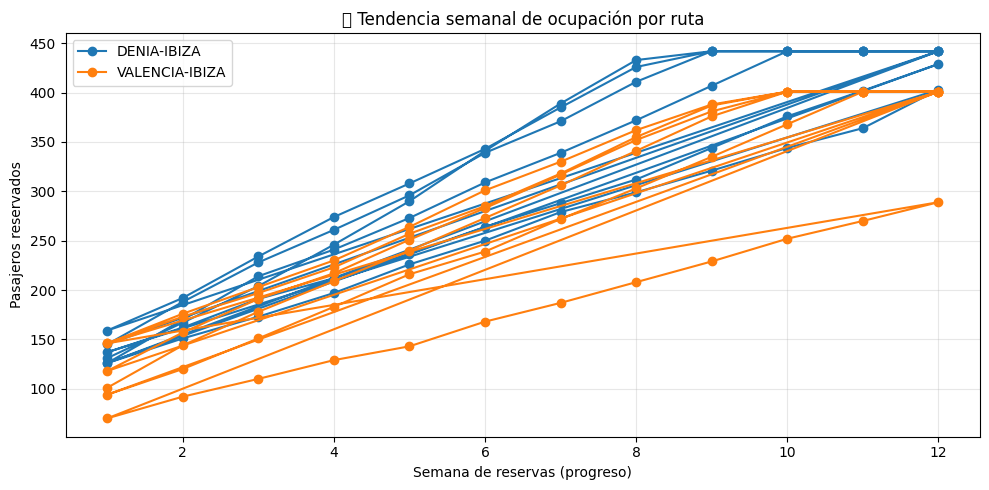

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

# === CONFIGURACIÓN ===
np.random.seed(42)
routes = ["VALENCIA-IBIZA", "DENIA-IBIZA"]
# Capacidad aleatoria entre 350 y 450
capacity = {r: np.random.randint(350, 451) for r in routes}

weeks_ahead = 6          # semanas futuras de salida
reservations_weeks = 12  # semanas previas con reservas históricas
start_date = datetime.now().date()

# === 1️⃣ Plan de salidas semanales ===
def generate_departure_plan(routes, weeks_ahead, start_date, capacity):
    departures = []
    for route in routes:
        for i in range(weeks_ahead):
            departure_date = start_date + timedelta(days=i * 7)
            departures.append({
                "route": route,
                "departure_date": departure_date,
                "capacity": capacity[route],
            })
    return pd.DataFrame(departures)


# === 2️⃣ Simular reservas semanales más regulares ===
def simulate_weekly_bookings_regular(departures_df, reservations_weeks):
    records = []
    for _, dep in departures_df.iterrows():
        # inicio con cierta base de reservas (no cero)
        base_rate = np.random.uniform(0.15, 0.30)   # 15–30% del barco lleno al inicio
        growth_rate = np.random.uniform(0.05, 0.10) # crecimiento semanal regular
        booked = int(dep.capacity * base_rate)

        for w in range(1, reservations_weeks + 1):
            # cada semana aumentan las reservas de forma controlada
            booked = booked + int(dep.capacity * growth_rate)
            # añadir una leve irregularidad realista
            noise = np.random.normal(0, dep.capacity * 0.01)
            booked = int(np.clip(booked + noise, 0, dep.capacity))

            records.append({
                "route": dep.route,
                "departure_date": dep.departure_date,
                "week_number": w,
                "booked_passengers": booked,
                "remaining_seats": dep.capacity - booked,
                "occupancy_rate": booked / dep.capacity
            })
    return pd.DataFrame(records)


# === 3️⃣ Analizar rutas ===
def analyze_route_week(df, week):
    week_df = df[df["week_number"] == week]
    alerts = []
    for _, row in week_df.iterrows():
        if row["occupancy_rate"] > 0.85:
            alerts.append((row["route"], row["departure_date"], "⚠️ Alta demanda — considerar ruta adicional"))
        elif row["occupancy_rate"] < 0.4:
            alerts.append((row["route"], row["departure_date"], "⬇️ Baja demanda — considerar reducir frecuencia"))
    return alerts


# === 4️⃣ Gráfico ===
def plot_reservations_over_time(df):
    plt.figure(figsize=(10, 5))
    for route, group in df.groupby("route"):
        group_sorted = group.sort_values(["departure_date", "week_number"])
        plt.plot(group_sorted["week_number"], group_sorted["booked_passengers"],
                 marker="o", linestyle="-", label=f"{route}")
    plt.title("📊 Tendencia semanal de ocupación por ruta")
    plt.xlabel("Semana de reservas (progreso)")
    plt.ylabel("Pasajeros reservados")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# === 5️⃣ Ejecutar ===
departures_df = generate_departure_plan(routes, weeks_ahead, start_date, capacity)
progress_df = simulate_weekly_bookings_regular(departures_df, reservations_weeks)
alerts_week_4 = analyze_route_week(progress_df, 4)

# === 6️⃣ Resultados ===
print("📅 Ejemplo de evolución de reservas:")
print(progress_df.head(10))

print("\n📈 Alertas semana 4:")
for a in alerts_week_4:
    print(f"{a[0]} / {a[1]} → {a[2]}")

progress_df.to_csv("ocupacion_regular.csv", index=False)
print("\n✅ Archivo generado: ocupacion_regular.csv")

plot_reservations_over_time(progress_df)


In [ ]:
progress_df.keys()

Index(['route', 'departure_date', 'week_number', 'booked_passengers',
       'remaining_seats', 'occupancy_rate'],
      dtype='object')

In [ ]:
from __future__ import annotations
import os
from dataclasses import dataclass
from typing import List, Tuple, Optional

import numpy as np
import pandas as pd
from datetime import datetime, timedelta
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Ajustes visuales
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.grid"] = True


In [ ]:
@dataclass
class Config:
    input_csv: str = "/content/ocupacion_regular.csv"   # CSV de entrada (usa tu ruta)
    output_csv: str = "forecast_demand_analysis.csv"
    plots_dir: str = "/content/plots"
    rolling_window: int = 3
    low_q: float = 0.2
    high_q: float = 0.8

CFG = Config()


In [ ]:
REQUIRED_COLUMNS = ["route", "departure_date", "week_number", "booked_passengers", "occupancy_rate"]

def ensure_dataframe(df_or_path: pd.DataFrame | str) -> pd.DataFrame:
    """Valida y prepara el DataFrame inicial."""
    if isinstance(df_or_path, pd.DataFrame):
        df = df_or_path.copy()
    else:
        df = pd.read_csv(df_or_path, parse_dates=["departure_date"])
    missing = [c for c in REQUIRED_COLUMNS if c not in df.columns]
    if missing:
        raise ValueError(f"Faltan columnas requeridas: {missing}")
    df["departure_date"] = pd.to_datetime(df["departure_date"])
    for col in ["week_number", "booked_passengers", "occupancy_rate"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df = df.dropna(subset=["route","departure_date","week_number","booked_passengers","occupancy_rate"])
    return df.sort_values(["route","departure_date","week_number"]).reset_index(drop=True)


def simulate_expected_demand(df: pd.DataFrame) -> pd.DataFrame:
    """Calcula demanda esperada media = booked / occupancy_rate."""
    df = df.copy()
    df["occupancy_rate"] = df["occupancy_rate"].replace(0, np.nan)
    df["expected_demand_mean"] = df["booked_passengers"] / df["occupancy_rate"]
    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["expected_demand_mean"])
    print(f"✅ [simulate_expected_demand] Filas válidas: {len(df)}")
    return df


def rolling_stats_with_bands(df: pd.DataFrame, window: int, low_q: float, high_q: float) -> pd.DataFrame:
    """Cálculo de medias móviles y bandas de cuantiles."""
    df = df.copy()
    def _apply(group):
        x = group["expected_demand_mean"]
        group["moving_avg_demand"] = x.rolling(window, min_periods=1).mean()
        group["low_band"] = x.rolling(window, min_periods=1).quantile(low_q)
        group["high_band"] = x.rolling(window, min_periods=1).quantile(high_q)
        return group
    df = df.groupby("route", group_keys=False).apply(_apply)
    print("✅ [rolling_stats_with_bands] Cálculo completado.")
    return df


def linear_trend_on_moving_avg(df: pd.DataFrame) -> Tuple[pd.DataFrame, List[Tuple[str,float,float,float,int]]]:
    """Ajusta una regresión lineal sobre la media móvil por ruta."""
    df = df.copy()
    df["linear_pred"] = np.nan
    results = []
    for route, g in df.groupby("route"):
        daily = g.groupby("departure_date", as_index=False)["moving_avg_demand"].mean().dropna()
        if len(daily) < 2:
            continue
        X = np.arange(len(daily)).reshape(-1, 1)
        y = daily["moving_avg_demand"].values
        model = LinearRegression().fit(X, y)
        daily["linear_pred"] = model.predict(X)
        pred_map = dict(zip(daily["departure_date"], daily["linear_pred"]))
        df.loc[df["route"] == route, "linear_pred"] = df.loc[df["route"] == route, "departure_date"].map(pred_map)
        results.append((route, float(model.coef_[0]), float(model.intercept_), float(model.score(X, y)), len(daily)))
    print("✅ [linear_trend_on_moving_avg] Regresiones calculadas.")
    return df, results


def run_pipeline(input_csv: str, cfg: Config = CFG) -> Tuple[pd.DataFrame, List[Tuple[str,float,float,float,int]]]:
    """Ejecuta el flujo completo y guarda el CSV resultante."""
    df = ensure_dataframe(input_csv)
    df = simulate_expected_demand(df)
    df = rolling_stats_with_bands(df, cfg.rolling_window, cfg.low_q, cfg.high_q)
    df, trends = linear_trend_on_moving_avg(df)
    df.to_csv(cfg.output_csv, index=False)
    print(f"✅ [export] Archivo guardado en {cfg.output_csv}")
    return df, trends


In [ ]:
def plot_route_trend_with_bands(df: pd.DataFrame, route: str, save_path: Optional[str] = None):
    """Grafica demanda esperada, bandas y regresión lineal por ruta."""
    g = df[df["route"] == route].sort_values(["departure_date", "week_number"])
    daily = g.groupby("departure_date", as_index=False).agg(
        expected_demand_mean=("expected_demand_mean", "mean"),
        moving_avg_demand=("moving_avg_demand", "mean"),
        low_band=("low_band", "mean"),
        high_band=("high_band", "mean"),
        linear_pred=("linear_pred", "mean")
    ).dropna(subset=["expected_demand_mean"])

    if daily.empty:
        print(f"[plot] Sin datos para {route}")
        return

    x_num = mdates.date2num(pd.to_datetime(daily["departure_date"]))

    fig, ax = plt.subplots()
    ax.plot_date(x_num, daily["expected_demand_mean"], "o", label="Demanda esperada")
    ax.fill_between(x_num, daily["low_band"], daily["high_band"], alpha=0.15, label="Banda baja/alta")
    ax.plot_date(x_num, daily["moving_avg_demand"], "-", label="Media móvil")
    if daily["linear_pred"].notna().any():
        ax.plot_date(x_num, daily["linear_pred"], "--", label="Regresión (media móvil)")
    ax.set_title(f"Tendencia de demanda — {route}")
    ax.set_xlabel("Fecha de salida")
    ax.set_ylabel("Demanda (pasajeros)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    plt.xticks(rotation=30)
    plt.tight_layout()

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()


✅ [simulate_expected_demand] Filas válidas: 144
✅ [rolling_stats_with_bands] Cálculo completado.
✅ [linear_trend_on_moving_avg] Regresiones calculadas.
✅ [export] Archivo guardado en forecast_demand_analysis.csv


/tmp/ipython-input-1414533571.py:38: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("route", group_keys=False).apply(_apply)
/tmp/ipython-input-3831700900.py:19: MatplotlibDeprecationWarning: The plot_date function was deprecated in Matplotlib 3.9 and will be removed in 3.11. Use plot instead.
  ax.plot_date(x_num, daily["expected_demand_mean"], "o", label="Demanda esperada")
/tmp/ipython-input-3831700900.py:21: MatplotlibDeprecationWarning: The plot_date function was deprecated in Matplotlib 3.9 and will be removed in 3.11. Use plot instead.
  ax.plot_date(x_num, daily["moving_avg_demand"], "-", label="Media móvil")
/tmp/ipython-input-3831700900.py:23: MatplotlibDeprecationWarning

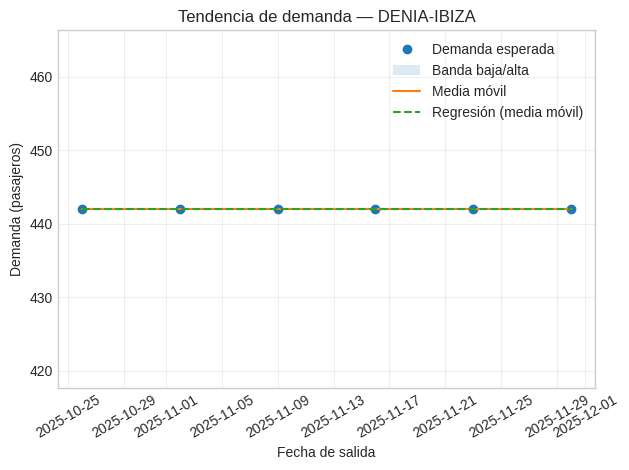

/tmp/ipython-input-3831700900.py:19: MatplotlibDeprecationWarning: The plot_date function was deprecated in Matplotlib 3.9 and will be removed in 3.11. Use plot instead.
  ax.plot_date(x_num, daily["expected_demand_mean"], "o", label="Demanda esperada")
/tmp/ipython-input-3831700900.py:21: MatplotlibDeprecationWarning: The plot_date function was deprecated in Matplotlib 3.9 and will be removed in 3.11. Use plot instead.
  ax.plot_date(x_num, daily["moving_avg_demand"], "-", label="Media móvil")
/tmp/ipython-input-3831700900.py:23: MatplotlibDeprecationWarning: The plot_date function was deprecated in Matplotlib 3.9 and will be removed in 3.11. Use plot instead.
  ax.plot_date(x_num, daily["linear_pred"], "--", label="Regresión (media móvil)")


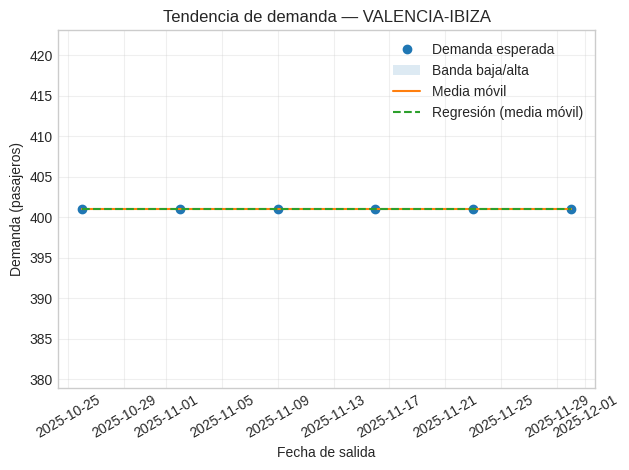


📁 Resultados generados:
- CSV: forecast_demand_analysis.csv
- Carpeta de gráficos: /content/plots


In [ ]:
# Ejecutar el flujo completo
df_result, trend_info = run_pipeline(CFG.input_csv, CFG)

# Crear carpeta para gráficos
os.makedirs(CFG.plots_dir, exist_ok=True)

# Guardar un PNG por ruta
for route in df_result["route"].dropna().unique():
    save_path = os.path.join(CFG.plots_dir, f"{route}.png")
    plot_route_trend_with_bands(df_result, route, save_path)

print(f"\n📁 Resultados generados:\n- CSV: {CFG.output_csv}\n- Carpeta de gráficos: {CFG.plots_dir}")


In [ ]:
cols = ["route","slope","intercept","r2","n"]
trend_df = pd.DataFrame(trend_info, columns=cols) if trend_info else pd.DataFrame(columns=cols)

print("\n📊 Resumen de tendencias por ruta:\n")
display(trend_df)



📊 Resumen de tendencias por ruta:



,route,slope,intercept,r2,n
0,DENIA-IBIZA,0.0,442.0,1.0,6
1,VALENCIA-IBIZA,0.0,401.0,1.0,6
